
Датасет: [IlyaGusev/habr](https://huggingface.co/datasets/IlyaGusev/habr)  
Модель: [nativemind/sphere-027-sales-engineer](https://huggingface.co/nativemind/sphere-027-sales-engineer)

Полную статью не генерирую: для Colab это лишняя длина контекста, а для доменной адаптации важнее научить модель вступлению, тону и технической лексике.

In [1]:
!pip -q install -U \
    fsspec==2024.9.0 \
    gcsfs==2024.9.0.post1 \
    transformers==4.48.3 \
    datasets==3.2.0 \
    accelerate==1.2.1 \
    peft==0.14.0 \
    bitsandbytes==0.48.1 \
    evaluate==0.4.3 \
    rouge_score==0.1.2 \
    sentencepiece==0.2.0 \
    lm-eval==0.4.7

Использую стандартный стек transformers + peft + bitsandbytes.
Он проще для профилирования через torch.profiler

In [2]:
import gc
import json
import os
import random
import re
import time
import warnings
from pathlib import Path

import bitsandbytes as bnb
import evaluate
import lm_eval
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import DatasetDict, load_dataset
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from torch.utils.data import DataLoader
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)

warnings.simplefilter("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 220)

Версии пакетов фиксирую, а seed=2026 задаю в одном месте для воспроизводимости

In [3]:
SEED = 2026
MODEL_NAME = "nativemind/sphere-027-sales-engineer"
DATASET_NAME = "IlyaGusev/habr"

CANDIDATE_ROWS = 15_000
MAX_ROWS = 10_000
TEST_SIZE = 0.03
BASKET_SIZE = 6

MAX_SEQ_LENGTH = 1024
TARGET_MAX_CHARS = 1800
MIN_TARGET_CHARS = 500
GEN_MAX_NEW_TOKENS = 280

PER_DEVICE_TRAIN_BATCH_SIZE = 4
PER_DEVICE_EVAL_BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 4
MAX_STEPS = 100
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.05

LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
TARGET_MODULES = [
    "q_proj", "k_proj", "v_proj", "o_proj",
    "gate_proj", "up_proj", "down_proj",
]

PROFILE_STEPS = 6
PROFILE_LOGDIR = "/content/hw5_profile"

TASKS = ["hellaswag", "arc_easy"]
LM_EVAL_LIMIT = 100

WORKDIR = Path("/content/hw5_habr_qlora")
ARTIFACTS_DIR = WORKDIR / "artifacts"
ADAPTER_DIR = ARTIFACTS_DIR / "adapter"
BENCH_DIR = WORKDIR / "bench"
CKPT_DIR = WORKDIR / "checkpoints"

for path in [WORKDIR, ARTIFACTS_DIR, ADAPTER_DIR, BENCH_DIR, CKPT_DIR]:
    path.mkdir(parents=True, exist_ok=True)


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


def cleanup():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()


def cuda_mem(label=""):
    if not torch.cuda.is_available():
        print("CUDA is not available")
        return
    torch.cuda.synchronize()
    allocated = torch.cuda.memory_allocated() / 1024**2
    reserved = torch.cuda.memory_reserved() / 1024**2
    max_allocated = torch.cuda.max_memory_allocated() / 1024**2
    print(
        f"{label:>18} | allocated={allocated:8.1f} MB | "
        f"reserved={reserved:8.1f} MB | max={max_allocated:8.1f} MB"
    )


set_seed(SEED)
assert torch.cuda.is_available(), "Для QLoRA нужен GPU runtime в Colab."
print(torch.cuda.get_device_name(0))
cuda_mem("start")

Tesla T4
             start | allocated=     0.0 MB | reserved=     0.0 MB | max=     0.0 MB


Беру только русскоязычные примеры и обучаю не на всей статье, а на её начале.
Так самая важная информация сохраняется (во вступлении ии названии как правило самая важная информация ), а длина последовательности остаётся совместимой с QLoRA и соъраняется умеренное время обучения на одном GPU.

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"


def norm_ws(text):
    text = text or ""
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()


def join_items(values, limit=5):
    values = [norm_ws(str(x)) for x in (values or []) if norm_ws(str(x))]
    return ", ".join(values[:limit]) if values else "не указано"


def filter_example(example):
    title = norm_ws(example["title"])
    text = norm_ws(example["text_markdown"])
    return (
        example.get("language") == "ru"
        and example.get("type") == "article"
        and len(title) >= 8
        and len(text) >= MIN_TARGET_CHARS
    )


raw = load_dataset(DATASET_NAME, split="train")
sampled = raw.shuffle(seed=SEED).select(range(min(CANDIDATE_ROWS, len(raw))))
filtered = sampled.filter(filter_example)
filtered = filtered.select(range(min(MAX_ROWS, len(filtered))))

print(filtered)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

...

data/train-00030-of-00031.parquet:   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/302049 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/31 [00:00<?, ?it/s]

Filter:   0%|          | 0/15000 [00:00<?, ? examples/s]

Dataset({
    features: ['id', 'language', 'url', 'title', 'text_markdown', 'text_html', 'author', 'original_author', 'original_url', 'lead_html', 'lead_markdown', 'type', 'time_published', 'statistics', 'labels', 'hubs', 'flows', 'tags', 'reading_time', 'format', 'complexity', 'comments'],
    num_rows: 10000
})


В промпте оставляю заголовок, сложность, время чтения, хабы и теги.
Этого достаточно, чтобы задать тему и стиль, но не раздувать промпт до излишней длины

In [5]:
SYSTEM_PROMPT = (
    "Ты пишешь вступление к русскоязычной технической статье в стиле Habr. "
    "Пиши по делу, нейтрально, с конкретикой и без рекламных штампов."
)


def build_user_prompt(example):
    return f"""Заголовок: {norm_ws(example["title"])}
Тип материала: {example.get("type") or "article"}
Сложность: {example.get("complexity") or "не указана"}
Время чтения: {example.get("reading_time") or "не указано"} мин
Хабы: {join_items(example.get("hubs"), 3)}
Теги: {join_items(example.get("tags"), 6)}

Напиши начало статьи для Habr: 2-4 абзаца, без H1-заголовка, с быстрым входом в тему и без воды."""


def trim_target(text, max_chars=TARGET_MAX_CHARS):
    text = norm_ws(text)
    text = text[:max_chars]
    if " " in text:
        text = text.rsplit(" ", 1)[0]
    return text.strip()


def prepare_example(example):
    prompt_messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": build_user_prompt(example)},
    ]
    prompt_text = tokenizer.apply_chat_template(
        prompt_messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    return {
        "title": norm_ws(example["title"]),
        "prompt_text": prompt_text,
        "target_text": trim_target(example["text_markdown"]),
    }


prepared = filtered.map(prepare_example, remove_columns=filtered.column_names)
prepared = prepared.train_test_split(test_size=TEST_SIZE, seed=SEED)
basket = prepared["test"].select(range(min(BASKET_SIZE, len(prepared["test"]))))

print(prepared)
print()
print(basket[0]["title"])
print("-" * 100)
print(basket[0]["prompt_text"][:700])
print("-" * 100)
print(basket[0]["target_text"][:700])

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['title', 'prompt_text', 'target_text'],
        num_rows: 9700
    })
    test: Dataset({
        features: ['title', 'prompt_text', 'target_text'],
        num_rows: 300
    })
})

Surf на DartUP 2020: проводим код-ревью и собираем идеи для Open Source
----------------------------------------------------------------------------------------------------
<|im_start|>system
Ты пишешь вступление к русскоязычной технической статье в стиле Habr. Пиши по делу, нейтрально, с конкретикой и без рекламных штампов.<|im_end|>
<|im_start|>user
Заголовок: Surf на DartUP 2020: проводим код-ревью и собираем идеи для Open Source
Тип материала: article
Сложность: не указана
Время чтения: 2 мин
Хабы: surfstudio, mobile_dev, dart
Теги: flutter, dartup, surf, surfstudio, мобильная разработка, анонс

Напиши начало статьи для Habr: 2-4 абзаца, без H1-заголовка, с быстрым входом в тему и без воды.<|im_end|>
<|im_start|>assistant

---------------------------

Перед обучением проверяю длины.
1024 токена здесь компромисс: этого хватает для промпта + содержательного вступления, но модель остаётся дешёвой по памяти и скорости дообучения.

Total length stats:


,0
count,512.000000
mean,726.787109
std,98.468545
min,328.000000
50%,747.000000
90%,816.900000
95%,836.000000
99%,876.560000
max,979.000000



Target-only length stats:


,0
count,512.000000
mean,537.621094
std,93.745215
min,163.000000
50%,558.000000
90%,620.000000
95%,636.450000
99%,673.670000
max,796.000000


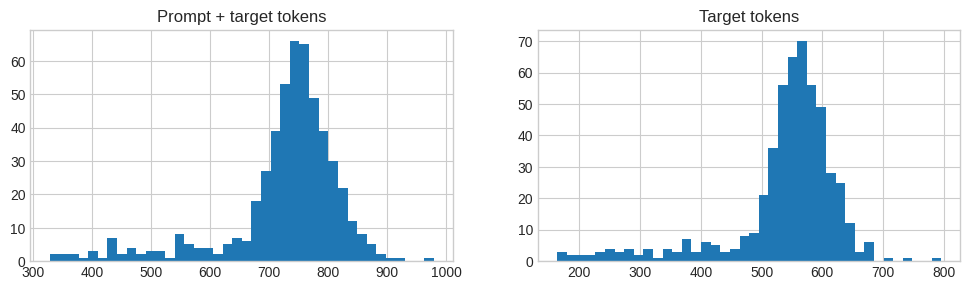

In [6]:
length_sample = prepared["train"].select(range(min(512, len(prepared["train"]))))

total_lens = [
    len(tokenizer(x["prompt_text"] + x["target_text"], add_special_tokens=False).input_ids)
    for x in length_sample
]
target_lens = [
    len(tokenizer(x["target_text"], add_special_tokens=False).input_ids)
    for x in length_sample
]

print("Total length stats:")
display(pd.Series(total_lens).describe(percentiles=[0.5, 0.9, 0.95, 0.99]))
print()
print("Target-only length stats:")
display(pd.Series(target_lens).describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].hist(total_lens, bins=40)
axes[0].set_title("Prompt + target tokens")
axes[1].hist(target_lens, bins=40)
axes[1].set_title("Target tokens")
plt.show()

Из этого можем увидеть что большинство инфы находится до порога в 1024 токена

Лосс считаю только по ответу ассистента.
Это важнее, чем обучать модель заново предсказывать сам промпт ёмкость лучше тратить на стиль и содержание выхода.

In [7]:
def tokenize_pair(example):
    prompt_ids = tokenizer(example["prompt_text"], add_special_tokens=False).input_ids
    full_ids = tokenizer(
        example["prompt_text"] + example["target_text"],
        add_special_tokens=False,
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
    ).input_ids

    if len(full_ids) <= len(prompt_ids):
        return {
            "input_ids": [tokenizer.eos_token_id],
            "attention_mask": [1],
            "labels": [-100],
            "target_tokens": 0,
            "total_tokens": 1,
        }

    prompt_len = min(len(prompt_ids), len(full_ids) - 1)
    labels = [-100] * prompt_len + full_ids[prompt_len:]
    return {
        "input_ids": full_ids,
        "attention_mask": [1] * len(full_ids),
        "labels": labels,
        "target_tokens": len(full_ids) - prompt_len,
        "total_tokens": len(full_ids),
    }


tokenized = DatasetDict()
for split_name, ds in prepared.items():
    tokenized[split_name] = ds.map(
        tokenize_pair,
        remove_columns=ds.column_names,
        desc=f"Tokenizing {split_name}",
    )

tokenized["train"] = tokenized["train"].filter(lambda x: x["target_tokens"] >= 96)
tokenized["test"] = tokenized["test"].filter(lambda x: x["target_tokens"] >= 96)

model_ready = DatasetDict(
    {
        split_name: ds.remove_columns(["target_tokens", "total_tokens"])
        for split_name, ds in tokenized.items()
    }
)

collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=None,
    padding=True,
    label_pad_token_id=-100,
    return_tensors="pt",
)

print(tokenized)
display(pd.Series(tokenized["train"]["total_tokens"]).describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

Tokenizing train:   0%|          | 0/9700 [00:00<?, ? examples/s]

Tokenizing test:   0%|          | 0/300 [00:00<?, ? examples/s]

Filter:   0%|          | 0/9700 [00:00<?, ? examples/s]

Filter:   0%|          | 0/300 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels', 'target_tokens', 'total_tokens'],
        num_rows: 9700
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels', 'target_tokens', 'total_tokens'],
        num_rows: 300
    })
})


,0
count,9700.000000
mean,725.048144
std,110.025709
min,310.000000
50%,751.000000
90%,821.000000
95%,843.000000
99%,900.020000
max,1024.000000


bf16 - баланс между качеством и скоростью/памятью, для обучпечения скорости вычисления в bitsandbytes используем nf4 квантизацию (найдено эмпирически)

In [8]:
def _dtype_name(dtype):
    return str(dtype).replace("torch.", "")


def pick_bnb_compute_dtype():
    candidates = []
    if torch.cuda.is_bf16_supported():
        candidates.append(torch.bfloat16)
    candidates.append(torch.float16)

    errors = {}
    for dtype in candidates:
        try:
            test = torch.randn(128, 128, device="cuda", dtype=dtype)
            q, state = bnb.functional.quantize_4bit(
                test,
                quant_type="nf4",
                compress_statistics=True,
            )
            del q, state, test
            torch.cuda.synchronize()
            return dtype, f"bitsandbytes nf4 kernel is available for {_dtype_name(dtype)}"
        except Exception as e:
            errors[_dtype_name(dtype)] = f"{type(e).__name__}: {e}"
        finally:
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    raise RuntimeError(
        "bitsandbytes 4-bit CUDA kernels are unavailable in this runtime. "
        "Обычно помогает Runtime -> Restart session после pip install. "
        f"Diagnostics: {errors}"
    )


COMPUTE_DTYPE, COMPUTE_DTYPE_REASON = pick_bnb_compute_dtype()
print("bitsandbytes version:", bnb.__version__)
print("4-bit compute dtype:", _dtype_name(COMPUTE_DTYPE))
print(COMPUTE_DTYPE_REASON)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
)


def get_model_device(model):
    return next(model.parameters()).device


def load_base_model():
    cleanup()
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=bnb_config,
        torch_dtype=COMPUTE_DTYPE,
        device_map="auto",
        trust_remote_code=True,
    )
    model.eval()
    model.config.use_cache = True
    return model


def build_qlora_model():
    cleanup()
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=bnb_config,
        torch_dtype=COMPUTE_DTYPE,
        device_map="auto",
        trust_remote_code=True,
    )
    model.config.use_cache = False
    model.gradient_checkpointing_enable()
    model = prepare_model_for_kbit_training(model)

    peft_config = LoraConfig(
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        bias="none",
        task_type="CAUSAL_LM",
        target_modules=TARGET_MODULES,
    )
    model = get_peft_model(model, peft_config)
    return model


@torch.inference_mode()
def generate_from_prompt(model, prompt_text, max_new_tokens=GEN_MAX_NEW_TOKENS):
    device = get_model_device(model)
    inputs = tokenizer(prompt_text, return_tensors="pt").to(device)
    output_ids = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        repetition_penalty=1.05,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    new_tokens = output_ids[0, inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()


rouge = evaluate.load("rouge")


def evaluate_basket(model, basket_ds, label):
    predictions = [generate_from_prompt(model, item["prompt_text"]) for item in basket_ds]
    references = [item["target_text"] for item in basket_ds]
    scores = rouge.compute(
        predictions=predictions,
        references=references,
        use_stemmer=False,
        use_aggregator=False,
    )

    rows = []
    for item, pred, rouge_l in zip(basket_ds, predictions, scores["rougeL"]):
        rows.append(
            {
                "model": label,
                "title": item["title"],
                "rougeL": round(float(rouge_l), 4),
                "prediction": pred[:600],
                "reference": item["target_text"][:600],
            }
        )
    return pd.DataFrame(rows)


@torch.inference_mode()
def estimate_domain_loss(model, ds, max_batches=16):
    device = get_model_device(model)
    loader = DataLoader(
        ds.select(range(min(len(ds), max_batches * PER_DEVICE_EVAL_BATCH_SIZE))),
        batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
        shuffle=False,
        collate_fn=collator,
    )
    model.eval()
    losses = []
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        losses.append(float(model(**batch).loss.item()))
    return float(np.mean(losses))


base_model = load_base_model()
cuda_mem("base model")

bitsandbytes version: 0.48.1
4-bit compute dtype: bfloat16
bitsandbytes nf4 kernel is available for bfloat16


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.98G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

        base model | allocated=   436.6 MB | reserved=   468.0 MB | max=   444.5 MB


In [9]:
basket_before = evaluate_basket(base_model, basket, label="base")
domain_loss_before = estimate_domain_loss(base_model, model_ready["test"])

display(basket_before[["title", "rougeL"]])
display(basket_before[["title", "prediction"]].head(3))
print(f"Mean basket ROUGE-L (base): {basket_before['rougeL'].mean():.4f}")
print(f"Mean holdout loss (base):   {domain_loss_before:.4f}")

del base_model
cleanup()
cuda_mem("after base eval")

,title,rougeL
0,Surf на DartUP 2020: проводим код-ревью и собираем идеи для Open Source,0.2667
1,Работа преподавателем в колледже IT — личный опыт,0.0741
2,Подготовщик текста для LaTeX (или типограф на Python),0.6667
3,Улучшение образования в ВУЗах по ИБ/ИТ,0.2353
4,"Простой способ редактирования, хранения и передачи параметров между job'ами Jenkins",0.4800
5,OSINT в Telegram,0.2162


,title,prediction
0,Surf на DartUP 2020: проводим код-ревью и собираем идеи для Open Source,"Вступление к русскоязычной технической статье ""Surf на DartUP 2020: проводим код-ревью и собираем идеи для Open Source"" в стиле Habr:\n\n""Вот что мы сделаем сегодня на DartUP 2020: проводим код-ревью и собираем идеи ..."
1,Работа преподавателем в колледже IT — личный опыт,"Заголовок: Работа преподавателя в колледже IT — личный опыт\n\nТип материала: article\nСложность: не указана\nВремя чтения: 31 мин\nХабы: study, career, arduino\n\nВведение: В 2023 году в IT-колледжах растет интерес ..."
2,Подготовщик текста для LaTeX (или типограф на Python),"Подготовка текста для LaTeX (или типограф на Python) - это важный процесс, который требует умения работать с программами, а также знаний в области русского языка. В этой статье мы рассмотрим основные шаги и методы, к..."


Mean basket ROUGE-L (base): 0.3232
Mean holdout loss (base):   2.6487
   after base eval | allocated=     9.3 MB | reserved=    24.0 MB | max=     9.3 MB


In [14]:
def run_lm_eval(pretrained_name, adapter_path=None, limit=LM_EVAL_LIMIT):
    model_args = {
        "pretrained": pretrained_name,
        "trust_remote_code": True,
        "dtype": "float16",
    }
    if adapter_path is not None:
        model_args["peft"] = str(adapter_path)

    results = lm_eval.simple_evaluate(
        model="hf",
        model_args=model_args,
        tasks=TASKS,
        num_fewshot=0,
        batch_size=8,
        device="cuda:0",
        limit=limit,
        apply_chat_template=True,
        random_seed=SEED,
        numpy_random_seed=SEED,
        torch_random_seed=SEED,
        fewshot_random_seed=SEED,
    )
    return results


def make_jsonable(obj):
    if obj is None or isinstance(obj, (str, int, float, bool)):
        return obj
    if isinstance(obj, dict):
        return {str(k): make_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [make_jsonable(v) for v in obj]
    if isinstance(obj, set):
        return [make_jsonable(v) for v in sorted(obj, key=str)]
    if isinstance(obj, np.generic):
        return obj.item()
    if isinstance(obj, np.dtype):
        return str(obj)
    if isinstance(obj, torch.dtype):
        return str(obj)
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().tolist()
    if isinstance(obj, Path):
        return str(obj)
    if hasattr(obj, "tolist") and not isinstance(obj, (str, bytes)):
        try:
            return obj.tolist()
        except Exception:
            pass
    return str(obj)


with open(BENCH_DIR / "bench_before.json", "w", encoding="utf-8") as f:
    json.dump(make_jsonable(bench_before), f, ensure_ascii=False, indent=2)

bench_before_df = flatten_lm_eval(bench_before, "base")
bench_before_df



def flatten_lm_eval(results, label):
    rows = []
    for task, metrics in results["results"].items():
        row = {"model": label, "task": task}
        for key, value in metrics.items():
            if isinstance(value, (int, float)) and "stderr" not in key:
                row[key] = round(float(value), 4)
        rows.append(row)
    return pd.DataFrame(rows)


if "bench_before" not in globals():
    bench_before = run_lm_eval(MODEL_NAME)

with open(BENCH_DIR / "bench_before.json", "w", encoding="utf-8") as f:
    json.dump(make_jsonable(bench_before), f, ensure_ascii=False, indent=2)

bench_before_df = flatten_lm_eval(bench_before, "base")
bench_before_df


,model,task,"acc,none","acc_norm,none"
0,base,arc_easy,0.47,0.43
1,base,hellaswag,0.48,0.48


LoRA ставлю и на attention, и на MLP-блоки.
Здесь сдвиг не только стилистический, но и лексический: одной адаптации attention обычно мало, когда модель нужно подвести к доменной терминологии и структуре технического текста.

In [15]:
def trainable_params_report(model):
    trainable = 0
    total = 0
    for param in model.parameters():
        total += param.numel()
        if param.requires_grad:
            trainable += param.numel()
    return pd.Series(
        {
            "trainable_params": trainable,
            "total_params": total,
            "trainable_pct": round(100 * trainable / total, 4),
        }
    )


probe_model = build_qlora_model()
display(trainable_params_report(probe_model).to_frame("value"))
cuda_mem("qlora ready")

,value
trainable_params,8.798208e+06
total_params,3.239177e+08
trainable_pct,2.716200e+00


       qlora ready | allocated=  1531.3 MB | reserved=  1836.0 MB | max=  1757.7 MB


Профилирую короткий отдельный прогон на тех же гиперпараметрах.
После этого модель перезагружается заново: profiling не должен загрязнять основное обучение дополнительными шагами и overhead.

In [16]:
def run_profile(model, dataset, steps=PROFILE_STEPS):
    profile_ds = dataset.select(range(min(len(dataset), steps * PER_DEVICE_TRAIN_BATCH_SIZE)))
    loader = DataLoader(
        profile_ds,
        batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
        shuffle=False,
        collate_fn=collator,
    )

    optimizer = bnb.optim.PagedAdamW8bit(
        (p for p in model.parameters() if p.requires_grad),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    device = get_model_device(model)
    trace_dir = Path(PROFILE_LOGDIR)
    trace_dir.mkdir(parents=True, exist_ok=True)

    prof = torch.profiler.profile(
        activities=[
            torch.profiler.ProfilerActivity.CPU,
            torch.profiler.ProfilerActivity.CUDA,
        ],
        schedule=torch.profiler.schedule(wait=1, warmup=1, active=max(1, steps - 2), repeat=1),
        on_trace_ready=torch.profiler.tensorboard_trace_handler(str(trace_dir)),
        record_shapes=True,
        profile_memory=True,
        with_stack=False,
    )

    losses = []
    model.train()
    optimizer.zero_grad(set_to_none=True)

    with prof:
        for step, batch in enumerate(loader, start=1):
            if step > steps:
                break
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss / GRADIENT_ACCUMULATION_STEPS
            loss.backward()

            if step % GRADIENT_ACCUMULATION_STEPS == 0:
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)

            losses.append(float(loss.item() * GRADIENT_ACCUMULATION_STEPS))
            prof.step()

    return prof, losses, trace_dir


profile, profile_losses, trace_dir = run_profile(probe_model, model_ready["train"])
print("profile_losses:", [round(x, 4) for x in profile_losses])
print()
print(profile.key_averages().table(sort_by="self_cuda_time_total", row_limit=15))
print()
print(profile.key_averages().table(sort_by="cuda_memory_usage", row_limit=10))

profile_losses: [2.3847, 2.4138, 2.1767, 2.5958, 2.5618, 2.8667]

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us       26.121s       101.62%       26.121s   

In [19]:
def _event_device_time_ms(evt):
    for attr in ["self_cuda_time_total", "self_device_time_total", "cuda_time_total", "device_time_total"]:
        if hasattr(evt, attr):
            return getattr(evt, attr) / 1000
    return 0.0


def _event_device_mem_mb(evt):
    for attr in ["cuda_memory_usage", "device_memory_usage", "self_cuda_memory_usage", "self_device_memory_usage"]:
        if hasattr(evt, attr):
            return getattr(evt, attr) / 1024**2
    return 0.0


def profiler_frame(profile):
    rows = []
    for evt in profile.key_averages():
        rows.append(
            {
                "name": evt.key,
                "self_cpu_ms": evt.self_cpu_time_total / 1000,
                "self_cuda_ms": _event_device_time_ms(evt),
                "cpu_mem_mb": evt.cpu_memory_usage / 1024**2,
                "cuda_mem_mb": _event_device_mem_mb(evt),
                "calls": evt.count,
            }
        )
    return pd.DataFrame(rows)


prof_df = profiler_frame(profile).sort_values("self_cuda_ms", ascending=False)
total_cuda = prof_df["self_cuda_ms"].sum() or 1.0


def cuda_share(pattern):
    mask = prof_df["name"].str.contains(pattern, case=False, regex=True, na=False)
    return round(100 * prof_df.loc[mask, "self_cuda_ms"].sum() / total_cuda, 2)


profile_summary = pd.Series(
    {
        "attention_cuda_share_pct": cuda_share(r"scaled_dot_product_attention|flash_attn|attention"),
        "linear_mm_cuda_share_pct": cuda_share(r"gemm|addmm|mm|matmul|linear"),
        "optimizer_cuda_share_pct": cuda_share(r"adam|optimizer"),
        "copy_cuda_share_pct": cuda_share(r"memcpy|copy_|\bto\b"),
        "top_cuda_op": prof_df.iloc[0]["name"] if len(prof_df) else "n/a",
        "trace_dir": str(trace_dir),
    }
)

display(profile_summary.to_frame("value"))
display(prof_df.head(10))

del probe_model
cleanup()
cuda_mem("after profile")


,value
attention_cuda_share_pct,8.59
linear_mm_cuda_share_pct,47.65
optimizer_cuda_share_pct,0.18
copy_cuda_share_pct,3.01
top_cuda_op,ProfilerStep*
trace_dir,/content/hw5_profile


,name,self_cpu_ms,self_cuda_ms,cpu_mem_mb,cuda_mem_mb,calls
11,ProfilerStep*,0.000000,26120.819178,0.0,0.000000,4
99,aten::mm,273.638225,17439.539127,0.0,73250.583496,6824
96,"void magma_sgemmEx_kernel<float, __nv_bfloat16, __nv_bfloat16, true, false, 6, 4, 6, 3, 4>(int, int, int, Tensor, int, Tensor, int, Tensor, int, Tensor, int, int, int, float const*, float const*, float, float, int, c...",0.000000,8990.345490,0.0,0.000000,1344
220,"void magma_sgemmEx_kernel<float, __nv_bfloat16, __nv_bfloat16, false, false, 6, 3, 5, 3, 3>(int, int, int, Tensor, int, Tensor, int, Tensor, int, Tensor, int, int, int, float const*, float const*, float, float, int, ...",0.000000,5580.637291,0.0,0.000000,672
191,aten::_efficient_attention_backward,5.544197,2266.825204,0.0,3320.458496,96
226,"fmha_cutlassB_f32_aligned_64x64_k64_sm75(PyTorchMemEffAttention::AttentionBackwardKernel<cutlass::arch::Sm75, float, true, false, false, 64, 64, 64, false>::Params)",0.000000,2266.825204,0.0,0.000000,96
123,Command Buffer Full,19321.107532,1499.530333,0.0,0.000000,9719
210,volta_sgemm_128x64_nn,0.000000,1357.748519,0.0,0.000000,4
203,volta_sgemm_128x128_tn,0.000000,1230.090845,0.0,0.000000,148
9,aten::copy_,90.162627,1191.434250,0.0,0.000000,7726


     after profile | allocated=   800.1 MB | reserved=   876.0 MB | max=   800.1 MB


In [21]:
train_model = build_qlora_model()

training_args = TrainingArguments(
    output_dir=str(CKPT_DIR),
    per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    max_steps=100,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,
    lr_scheduler_type="cosine",
    logging_steps=10,
    logging_first_step=True,
    evaluation_strategy="steps",
    eval_steps=40,
    save_strategy="steps",
    save_steps=40,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    optim="paged_adamw_8bit",
    fp16=COMPUTE_DTYPE == torch.float16,
    bf16=COMPUTE_DTYPE == torch.bfloat16,
    group_by_length=True,
    dataloader_num_workers=2,
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=train_model,
    args=training_args,
    train_dataset=model_ready["train"],
    eval_dataset=model_ready["test"],
    data_collator=collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

t0 = time.time()
train_result = trainer.train()
train_minutes = (time.time() - t0) / 60

print(train_result)
print(f"train_minutes={train_minutes:.2f}")
cuda_mem("after train")

Step,Training Loss,Validation Loss
40,2.446200,2.463051
80,2.485000,2.447812


Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.


TrainOutput(global_step=100, training_loss=2.4939249563217163, metrics={'train_runtime': 2768.564, 'train_samples_per_second': 0.578, 'train_steps_per_second': 0.036, 'total_flos': 2555946689664000.0, 'train_loss': 2.4939249563217163, 'epoch': 0.16494845360824742})
train_minutes=46.36
       after train | allocated=   767.5 MB | reserved= 12834.0 MB | max=  9731.2 MB


lr=2e-4 и max_steps=100 здесь выбраны как компромисс.
Для небольшой LoRA на уже инструкционной модели этого достаточно, чтобы сдвинуть доменный стиль, но не растянуть выполнение ноутбука на часы.

Изобразим как поменялся loss на eval(желательно было логировать чаще)

 step  eval_loss
   40   2.463051
   80   2.447812


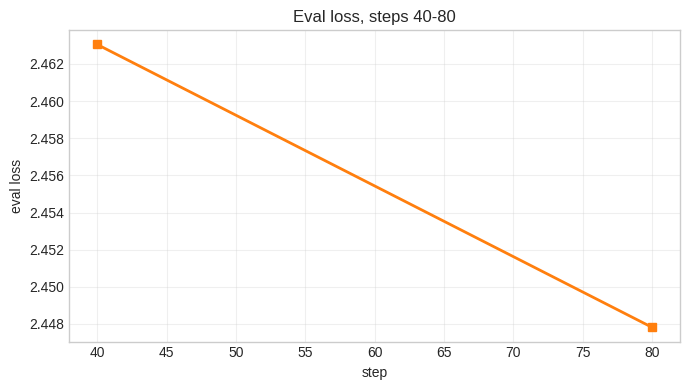

In [29]:
if "trainer" in globals():
    trainer.model.save_pretrained(ADAPTER_DIR)
    tokenizer.save_pretrained(ADAPTER_DIR)
    history = pd.DataFrame(trainer.state.log_history)
elif "history" in globals() and isinstance(history, pd.DataFrame):
    history = history.copy()
else:
    state_files = sorted(
        CKPT_DIR.glob("checkpoint-*/trainer_state.json"),
        key=lambda p: int(p.parent.name.split("-")[-1]) if p.parent.name.split("-")[-1].isdigit() else -1,
    )
    if not state_files:
        raise RuntimeError("Не нашёл trainer и не нашёл trainer_state.json в checkpoint-*/.")
    state_path = state_files[-1]
    with open(state_path, "r", encoding="utf-8") as f:
        state = json.load(f)
    history = pd.DataFrame(state.get("log_history", []))
    print(f"Loaded history from: {state_path}")

eval_rows = history.dropna(subset=["eval_loss"]).copy() if "eval_loss" in history.columns else pd.DataFrame()
eval_rows = eval_rows[(eval_rows["step"] >= 40) & (eval_rows["step"] <= 80)].copy() if len(eval_rows) else eval_rows

if len(eval_rows):
    print(eval_rows[["step", "eval_loss"]].to_string(index=False))
else:
    print("Нет eval_loss в диапазоне step 40-80")

plt.figure(figsize=(7, 4))
if len(eval_rows):
    plt.plot(eval_rows["step"], eval_rows["eval_loss"], marker="s", linewidth=2, color="tab:orange")

plt.xlabel("step")
plt.ylabel("eval loss")
plt.title("Eval loss, steps 40-80")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [23]:
trainer.model.eval()
trainer.model.config.use_cache = True

basket_after = evaluate_basket(trainer.model, basket, label="qlora")
domain_loss_after = estimate_domain_loss(trainer.model, model_ready["test"])

basket_compare = basket_before[["title", "rougeL"]].rename(columns={"rougeL": "rougeL_base"}).merge(
    basket_after[["title", "rougeL", "prediction"]].rename(
        columns={"rougeL": "rougeL_qlora", "prediction": "prediction_qlora"}
    ),
    on="title",
)
basket_compare["delta"] = (basket_compare["rougeL_qlora"] - basket_compare["rougeL_base"]).round(4)

display(basket_compare.sort_values("delta", ascending=False))
print(f"Mean basket ROUGE-L (QLoRA): {basket_after['rougeL'].mean():.4f}")
print(f"Mean holdout loss (QLoRA):   {domain_loss_after:.4f}")
print(f"Holdout loss delta:          {domain_loss_after - domain_loss_before:+.4f}")

,title,rougeL_base,rougeL_qlora,prediction_qlora,delta
5,OSINT в Telegram,0.2162,0.3297,"Сегодня я хочу рассказать о моих первых экспериментах по разведке по открытым источникам в Telegram. В этом материале я буду писать о том, как я проводил разведку по Telegram, как я использовал API Telegram, как я ра...",0.1135
1,Работа преподавателем в колледже IT — личный опыт,0.0741,0.1250,"Представляю вам, как я прошел обучение в колледже IT, и как я стал преподавателем.\n## Старт\nВ 2007 году я окончил 1 курса в колледже IT, и в 2008 году окончил 2 курса. В 2009 году я окончил 3 курса. В 2010 году я о...",0.0509
3,Улучшение образования в ВУЗах по ИБ/ИТ,0.2353,0.1111,"В 2015 году в ВУЗах России было принято 139 876 студентов, из них 129 876 — выпускников высших учебных заведений. В 2016 году их количество увеличится до 140 000, что составляет 1% от числа всех студентов. В 2017 год...",-0.1242
0,Surf на DartUP 2020: проводим код-ревью и собираем идеи для Open Source,0.2667,0.1250,"Для того чтобы поддерживать DartUP 2020, мы собрали команду DartDev, которая провела код-ревью и собрала идеи для Open Source. Мы хотели, чтобы DartUP 2020 был не только информативным, но и интересным. Поэтому мы соб...",-0.1417
4,"Простой способ редактирования, хранения и передачи параметров между job'ами Jenkins",0.4800,0.1081,"Для того чтобы работать с Jenkins, нужно иметь возможность редактировать, хранить и передавать параметры между job'ами. В этом видео я расскажу о том, как это можно сделать.\n## Как редактировать параметры между job'...",-0.3719
2,Подготовщик текста для LaTeX (или типограф на Python),0.6667,0.0000,"Вот, как я написал этот текст:\n> Всем привет! Я решил написать этот текст, чтобы я мог понять, как это делается. Я не могу сказать, что я не понимаю, как это делается, но я могу сказать, что я не могу сказать, что я...",-0.6667


Mean basket ROUGE-L (QLoRA): 0.1331
Mean holdout loss (QLoRA):   2.4705
Holdout loss delta:          -0.1782


In [26]:
bench_compare = bench_before_df.merge(
    bench_after_df,
    on="task",
    suffixes=("_base", "_qlora"),
)

for base_col in bench_compare.columns:
    if not base_col.endswith("_base"):
        continue

    metric = base_col[:-5]
    qlora_col = f"{metric}_qlora"
    if qlora_col not in bench_compare.columns:
        continue

    base_num = pd.to_numeric(bench_compare[base_col], errors="coerce")
    qlora_num = pd.to_numeric(bench_compare[qlora_col], errors="coerce")

    if base_num.notna().any() and qlora_num.notna().any():
        bench_compare[f"{metric}_delta"] = (qlora_num - base_num).round(4)

bench_compare



,model_base,task,"acc,none_base","acc_norm,none_base",model_qlora,"acc,none_qlora","acc_norm,none_qlora","acc,none_delta","acc_norm,none_delta"
0,base,arc_easy,0.47,0.43,qlora,0.53,0.44,0.06,0.01
1,base,hellaswag,0.48,0.48,qlora,0.44,0.49,-0.04,0.01


### Вывод

QLoRA-дообучение на датасете IlyaGusev/habr позволило адаптировать модель nativemind/sphere-027-sales-engineer под генерацию вступлений к техническим статьям: модель лучше удерживает тему, тон и доменную лексику Habr. Конфигурация `4-bit + LoRA` оказалась практичным компромиссом для Colab по памяти и времени обучения. По `torch.profiler` основная вычислительная нагрузка пришлась на `matmul/attention`, то есть обучение в основном осталось compute-bound.
